# **Tree Decision**

## **Librerías**

In [13]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [14]:
from sklearn.metrics import *
from sklearn.ensemble import *
from sklearn.pipeline import *
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.feature_selection import *
from sklearn.tree import DecisionTreeClassifier

## **Data**

In [15]:
df = pd.read_excel("../data/processed/df_to_model_frenel_21102025.xlsx")
df.head()

,target_tfg,pais_encuesta,grupo_origen,pais_nacimiento,edad,genero,grupo_etnico,nivel_escolaridad,regimen_salud,ocupacion,...,hacinamiento_hogar,hogar_migrantes,grupo_origen_ingles,ocupacion_agricola,imc,clasificacion_imc,grupo_edad,clasificacion_tfg,clasificacion_pa,creatinina_elevada
0,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,49,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,32.326531,Obesidad,41-50,Ligera (60-89),Hipertensión grado 2 (moderada),False
1,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,83,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador privado,Desempleado,...,NO,NO,AFRODESCENDANT,NO,22.206331,Normal,60+,Leve Moderada (45-59),Normal-alta,True
2,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,70,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,20.820940,Normal,60+,Ligera (60-89),Hipertensión grado 2 (moderada),False
3,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,25,Femenino,AFRODESCENDIENTE,Técnica,Asegurador público,Comerciante,...,SI,NO,AFRODESCENDANT,NO,23.738662,Normal,18-30,Ligera (60-89),Normal,True
4,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,64,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Desempleado,...,NO,NO,AFRODESCENDANT,NO,19.257029,Normal,60+,Leve Moderada (45-59),Normal,True


## **Preprocesamiento**

### **Selección de Variables**

In [16]:
columnas_a_excluir = ['pais_encuesta', 'grupo_origen', 'pais_nacimiento','edad', 'georeferenciacion', 'presion_arterial_sistolica', 
                      'presion_arterial_diastolica', 'creatinina', 'peso', 'talla', 'grupo_origen_ingles', 'imc', 'clasificacion_tfg',
                      'tasa_filtracion_glomerular', 'ocupacion', 'creatinina_elevada']
df.drop(columns=columnas_a_excluir, inplace=True)

### **Codificación Variables Categóricas**

In [17]:
df_col = df.drop(columns=['target_tfg'])
cat_cols = df_col.select_dtypes(include=['object', 'bool']).columns
num_cols = df_col.select_dtypes(include=['int64', 'float64']).columns
#print("Categorical columns: \n", cat_cols)
#print("Numerical columns: \n", num_cols)

In [18]:
encoder = OneHotEncoder(sparse_output = False, drop='first')  #La salida será una matriz densa (DataFrame de Pandas)
encoded = encoder.fit_transform(df[cat_cols])
df_encoded = pd.DataFrame(encoded, columns = encoder.get_feature_names_out(cat_cols))
df_modelo = pd.concat([df, df_encoded], axis = 1) # axis = 1: Indica que las columnas especificadas deben ser eliminadas
df_modelo = df_modelo.drop(cat_cols, axis = 1)

## **Modelo**

### **Conjuntos de `Train` y `Test`**

In [19]:
X = df_modelo.drop(columns=['target_tfg'])
y = df_modelo['target_tfg']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, stratify=y)
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (3657, 68)
Test set size: (1219, 68)


### **Implementación Modelo**

**Variables seleccionadas por el `SelectKbest`:** con estas 25 variables se entrenará el modelo.

In [21]:
pipeline = make_pipeline(SelectKBest(k=25), DecisionTreeClassifier(class_weight='balanced', random_state=11))
param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 7, 9, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 5],
    'decisiontreeclassifier__criterion': ['gini', 'entropy']}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor Recall en Train:", grid_search.best_score_)
print("Mejor Recall en Test:", recall_score(y_test, grid_search.predict(X_test))) # Ese es el promedio de los 5 folds

Mejores parámetros: {'decisiontreeclassifier__criterion': 'gini', 'decisiontreeclassifier__max_depth': 5, 'decisiontreeclassifier__min_samples_leaf': 1, 'decisiontreeclassifier__min_samples_split': 2}
Mejor Recall en Train: 0.6586564439576488
Mejor Recall en Test: 0.6594202898550725


### **Métricas y Resultados**

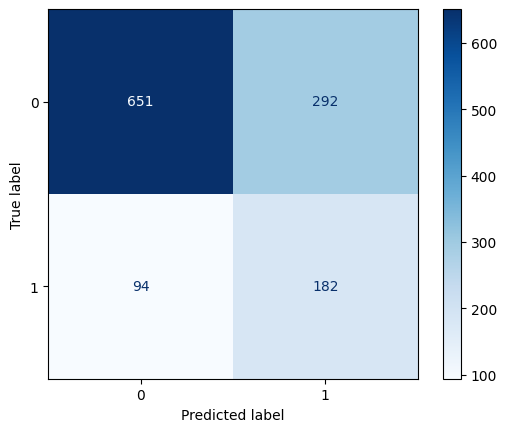

In [22]:
y_pred = grid_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')

In [23]:
# Predicciones en TRAIN
y_train_pred = grid_search.predict(X_train)
y_train_prob = grid_search.predict_proba(X_train)[:, 1]

# Predicciones en TEST
y_test_pred = grid_search.predict(X_test)
y_test_prob = grid_search.predict_proba(X_test)[:, 1]

# Crear tabla comparativa
resultados = {
    'Dataset': ['Train', 'Test'],
    'Precision': [
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],
    'Recall': [
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ],
    'F1 Score': [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_train, y_train_prob),
        roc_auc_score(y_test, y_test_prob)
    ]
}

metricas_tree = pd.DataFrame(resultados)
metricas_tree


,Dataset,Precision,Recall,F1 Score,ROC AUC
0,Train,0.393090,0.727382,0.510368,0.759559
1,Test,0.383966,0.659420,0.485333,0.718346


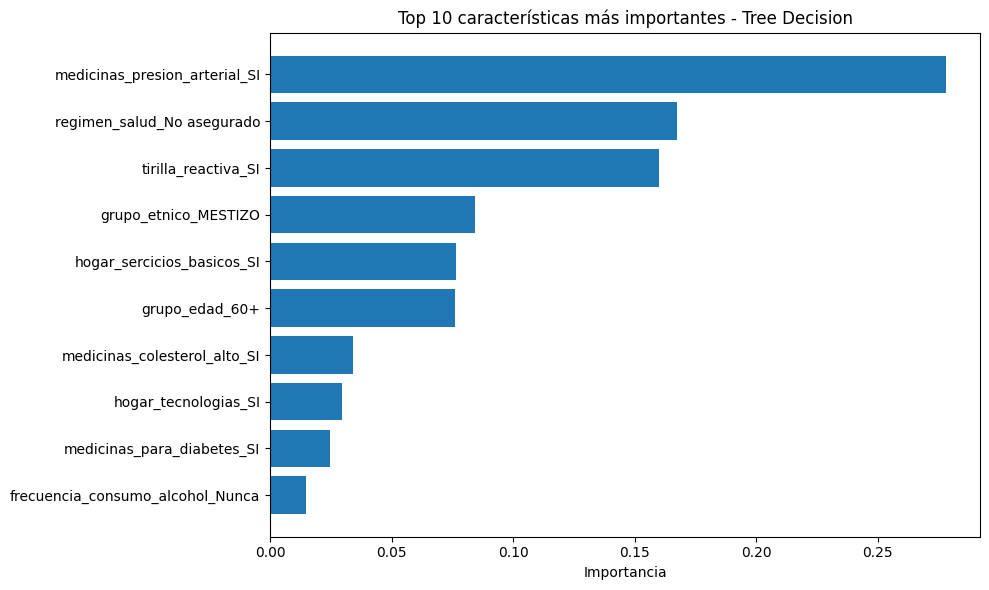

In [24]:
# Entrena el mejor modelo encontrado
best_model = grid_search.best_estimator_

# Recuperar el SelectKBest y el árbol
selector = best_model.named_steps['selectkbest']
tree = best_model.named_steps['decisiontreeclassifier']

# Obtener nombres de las variables seleccionadas
feature_names = X_train.columns
selected_features = feature_names[selector.get_support()]

# Importancias
importances = tree.feature_importances_

# Ordenar de mayor a menor
indices = np.argsort(importances)[::-1]

top_n = 10
top_indices = indices[:top_n]

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[top_indices][::-1], align='center')
plt.yticks(range(top_n), selected_features[top_indices][::-1])
plt.xlabel('Importancia')
plt.title(f'Top {top_n} características más importantes - Tree Decision')
plt.tight_layout()
plt.show()